# Dynamic Pricing for European Campsites — EDA & Methodology

## Business Problem

A pan-European camping operator manages **>400 campsites across 10 countries**, with >5 accommodation types per site, 4 market groups, and ~30 open weeks per year. This yields **≈250,000 prices to set annually**. The core question: *what price maximises bookings (and thus revenue)?*

---

## Proposed Methodology

### 1. Demand Forecasting Model
Train a model that predicts **incremental bookings at each week before arrival** (`HistoricalBookedNights`) given:
- Current price (`DiscountedPrice`) and last year's price (`DiscountedPriceLastYear`)
- Weeks remaining (`WeekBeforeArrival`) and booking curve state so far
- Product features: campsite, accommodation type, range, amenities (Airco, HotTub, Sleeps…)
- Context features: market group, special period, arrival month, temperature
- Prior-year signals: `HistoricalBookedNightsLastYear`, `CapacityLastYear`

Candidate models: **gradient-boosted trees (XGBoost/LightGBM)** for non-linear interactions, or a **negative binomial regression** for interpretability.

### 2. Price Optimisation
Given the demand forecast, find the price that maximises **expected revenue = price × expected total bookings**, subject to capacity constraints. Can be solved via:
- Grid search over a discretised price range
- Bayesian optimisation (fewer evaluations needed)
- Closed-form if the demand curve is approximately log-linear (price elasticity model)

### 3. Cold-Start Pricing (New Products)
For new campsites or accommodation types with no history:
- Initialise from **cluster averages** (campsite cluster + seasonal cluster)
- Use **comparable products** from the prior year
- Fall back to a **feature regression**: accommodation range, country, special period, Sleeps, Capacity

### 4. Human-in-the-Loop
Fully autonomous pricing is viable for standard weeks, but humans should:
- **Review** outlier recommendations (>20% deviation from last year's price)
- **Override** during promotional campaigns or strategic periods
- **Set guardrails**: minimum and maximum price per product type and country
- **Monitor** weekly dashboards: occupancy fill rate, revenue vs. forecast, price competitiveness

### 5. Implementation Path
1. **Offline training**: fit model on 2024 data, validate on held-out 2025 weeks
2. **Weekly scoring**: every Monday, score all open booking curves → recommended price per product
3. **A/B testing**: test new prices on a random subset; measure booking lift vs. control group
4. **Feedback loop**: retrain quarterly with updated actuals; track model drift

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': 'white',
    'grid.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

PALETTE = sns.color_palette('Set2', 8)
MARKET_COLORS = dict(zip(['Domestic', 'Benelux', 'DACH', 'Rest of Europe'],
                         sns.color_palette('tab10', 4)))
RANGE_COLORS = {'Budget': '#4CAF50', 'Mid': '#2196F3', 'Premium': '#9C27B0'}

print('Libraries loaded.')

Libraries loaded.


In [2]:
df = pd.read_csv('simulation_output.csv', low_memory=False)
df['WeekStartDate'] = pd.to_datetime(df['WeekStartDate'])
df['Year'] = df['WeekStartDate'].dt.year
df['OccupancyRate'] = (df['TotalBookedNights'] / df['Capacity']).clip(0, 1)
df['FillPct'] = df['OccupancyRate'] * 100

print(f"Rows: {len(df):,}   Columns: {df.shape[1]}")
print(f"Date range: {df['WeekStartDate'].min().date()} to {df['WeekStartDate'].max().date()}")
print(f"Unique campsites: {df['CampsiteCode'].nunique()}")
print(f"Unique booking curves: {df['ReservableOptionMarketGroupId'].nunique():,}")
print(f"Market groups: {sorted(df['MarketGroupCode'].unique())}")
print(f"Countries: {sorted(df['CampsiteCountry'].unique())}")

Rows: 3,130,816   Columns: 41
Date range: 2024-01-01 to 2025-12-22
Unique campsites: 142
Unique booking curves: 59,072
Market groups: ['Benelux', 'DACH', 'Domestic', 'Rest of Europe']
Countries: ['Almia', 'Ferrum', 'Fiore', 'Lental', 'Oblivia', 'Orre', 'Pasio', 'Ransei']


## 1. Dataset Overview

In [3]:
num_cols = ['DiscountedPrice', 'TotalBookedNights', 'HistoricalBookedNights',
            'Capacity', 'FillPct', 'AvgTemperature']
summary = df[num_cols].describe().T[['mean','std','min','25%','50%','75%','max']].round(2)
summary.index = ['Discounted Price (EUR)', 'Total Booked Nights', 'Incremental Bookings/week',
                 'Capacity (nights)', 'Occupancy Rate (%)', 'Avg Temperature (C)']
summary.columns = ['Mean','Std','Min','P25','Median','P75','Max']
print(summary.to_string())

                             Mean     Std     Min     P25  Median     P75     Max
Discounted Price (EUR)     212.69  132.31   42.06  107.12  184.34  273.79  665.06
Total Booked Nights         49.41   56.68    0.00    8.00   31.00   71.00  565.00
Incremental Bookings/week    0.93    2.34    0.00    0.00    0.00    1.00  133.00
Capacity (nights)          346.57  159.11  105.00  228.00  324.00  435.00  950.00
Occupancy Rate (%)          14.24   13.71    0.00    2.86   10.47   21.57   85.05
Avg Temperature (C)         12.54    7.50   -3.50    6.80   12.50   17.50   28.00


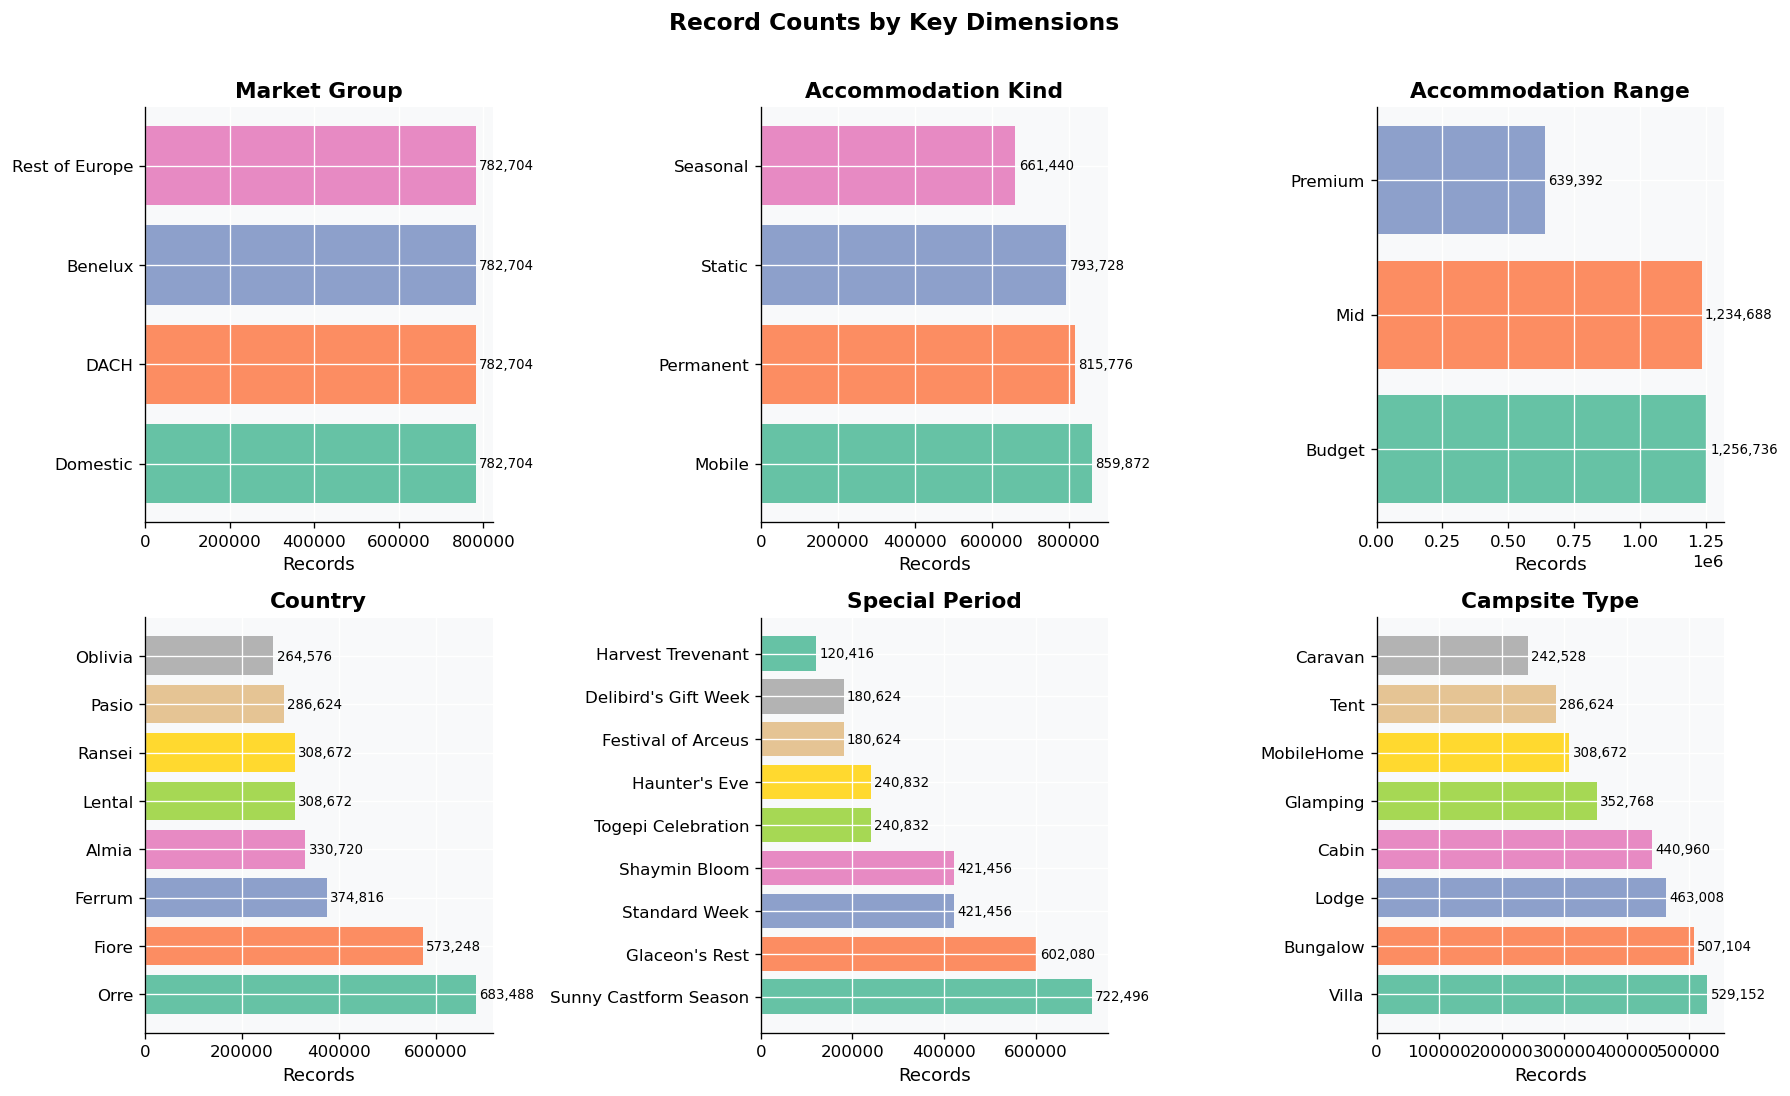

In [4]:
cat_counts = {
    'Market Group': df['MarketGroupCode'].value_counts(),
    'Accommodation Kind': df['AccoKindCode'].value_counts(),
    'Accommodation Range': df['AccommodationRange'].value_counts(),
    'Country': df['CampsiteCountry'].value_counts(),
    'Special Period': df['SpecialPeriodCode'].value_counts(),
    'Campsite Type': df['CampsiteType'].value_counts(),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (title, counts) in zip(axes, cat_counts.items()):
    bars = ax.barh(counts.index, counts.values, color=PALETTE[:len(counts)])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Records')
    for bar, val in zip(bars, counts.values):
        ax.text(val + counts.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:,}', va='center', fontsize=8)

fig.suptitle('Record Counts by Key Dimensions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig01_categorical_overview.png', bbox_inches='tight')
plt.show()

## 2. Price Distributions

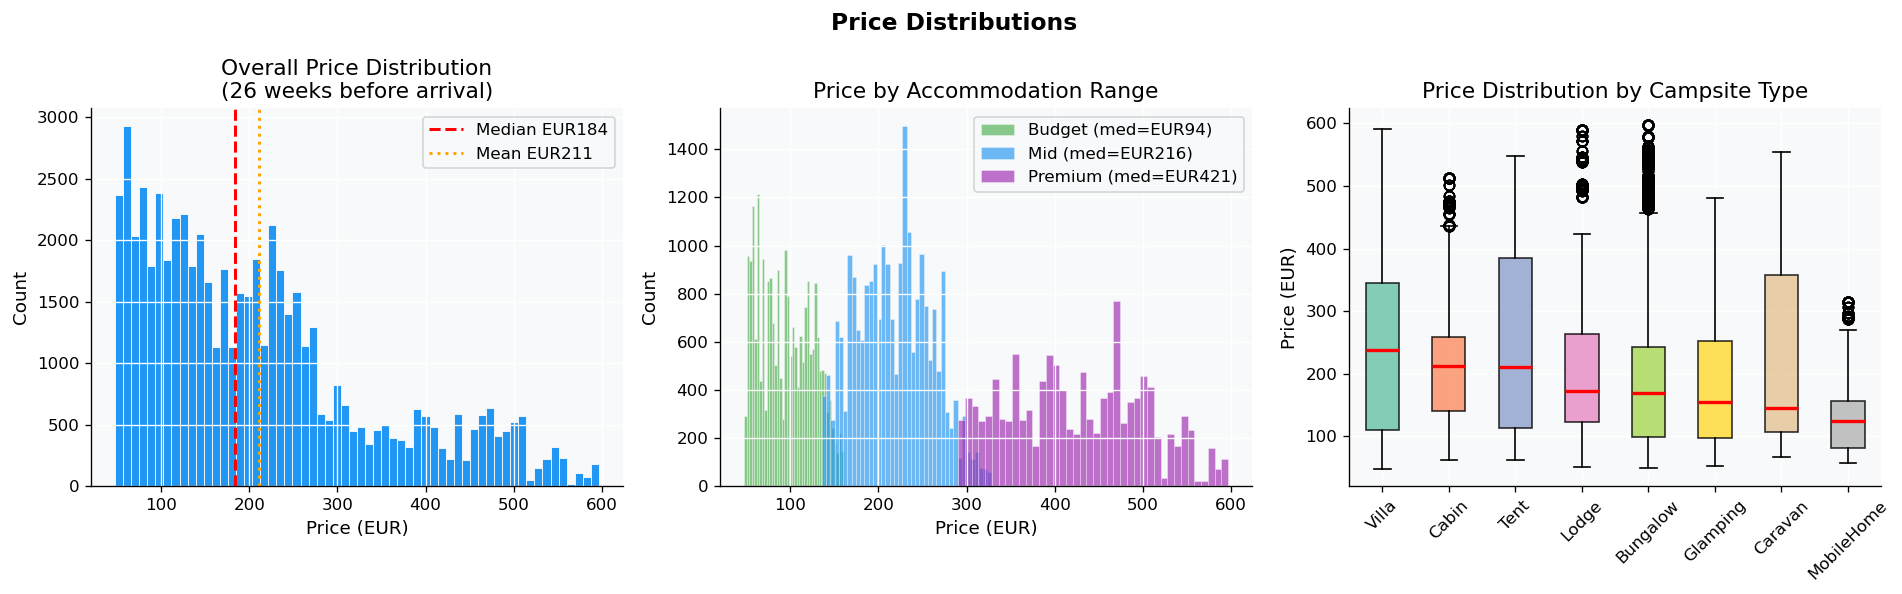

In [5]:
# Mid-horizon snapshot at 26 weeks before arrival
snap = df[df['WeekBeforeArrival'] == 26].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.hist(snap['DiscountedPrice'], bins=60, color='#2196F3', edgecolor='white', linewidth=0.5)
ax.axvline(snap['DiscountedPrice'].median(), color='red', lw=1.8, linestyle='--',
           label=f"Median EUR{snap['DiscountedPrice'].median():.0f}")
ax.axvline(snap['DiscountedPrice'].mean(), color='orange', lw=1.8, linestyle=':',
           label=f"Mean EUR{snap['DiscountedPrice'].mean():.0f}")
ax.set_xlabel('Price (EUR)')
ax.set_ylabel('Count')
ax.set_title('Overall Price Distribution\n(26 weeks before arrival)')
ax.legend()

ax = axes[1]
for rng, color in RANGE_COLORS.items():
    sub = snap[snap['AccommodationRange'] == rng]['DiscountedPrice']
    ax.hist(sub, bins=40, alpha=0.65, color=color,
            label=f'{rng} (med=EUR{sub.median():.0f})', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Price (EUR)')
ax.set_ylabel('Count')
ax.set_title('Price by Accommodation Range')
ax.legend()

ax = axes[2]
type_order = snap.groupby('CampsiteType')['DiscountedPrice'].median().sort_values(ascending=False).index
data_by_type = [snap[snap['CampsiteType'] == t]['DiscountedPrice'].values for t in type_order]
bp = ax.boxplot(data_by_type, labels=type_order, patch_artist=True,
                medianprops=dict(color='red', lw=2))
for patch, color in zip(bp['boxes'], sns.color_palette('Set2', len(type_order))):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_xlabel('')
ax.set_ylabel('Price (EUR)')
ax.set_title('Price Distribution by Campsite Type')
ax.tick_params(axis='x', rotation=45)

fig.suptitle('Price Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig02_price_distributions.png', bbox_inches='tight')
plt.show()

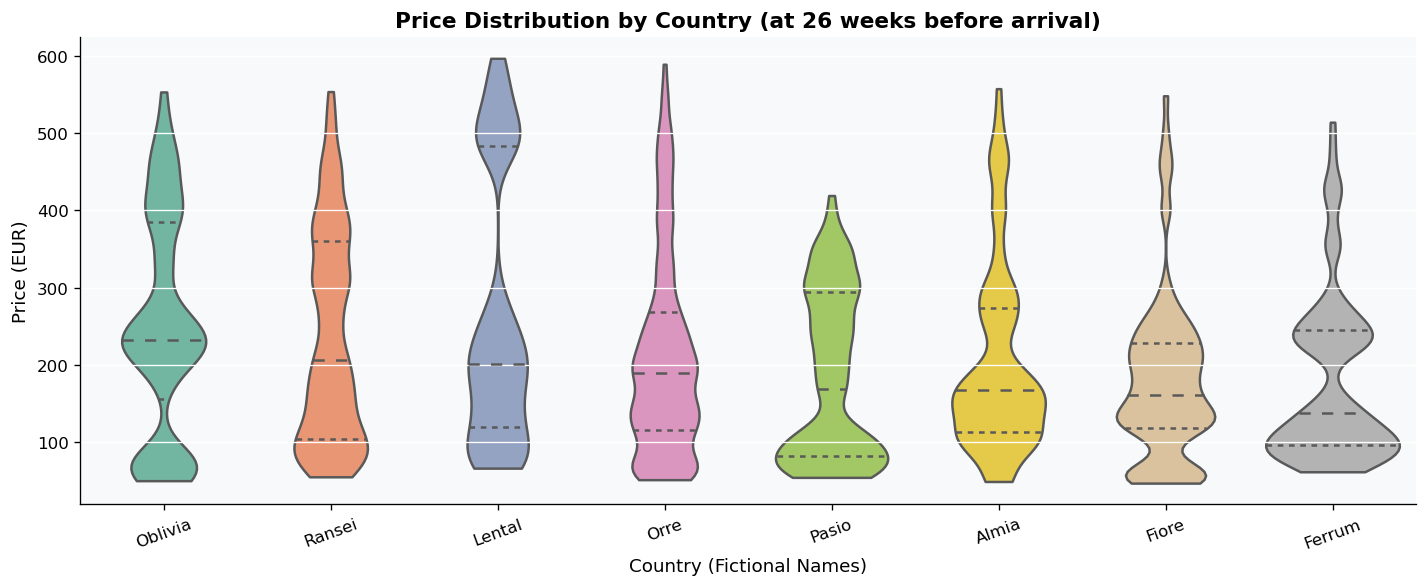

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
country_order = snap.groupby('CampsiteCountry')['DiscountedPrice'].median().sort_values(ascending=False).index
sns.violinplot(data=snap, x='CampsiteCountry', y='DiscountedPrice',
               order=country_order, palette='Set2', ax=ax, inner='quartile', cut=0)
ax.set_xlabel('Country (Fictional Names)')
ax.set_ylabel('Price (EUR)')
ax.set_title('Price Distribution by Country (at 26 weeks before arrival)', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('fig03_price_by_country.png', bbox_inches='tight')
plt.show()

## 3. Occupancy & Final Demand Patterns

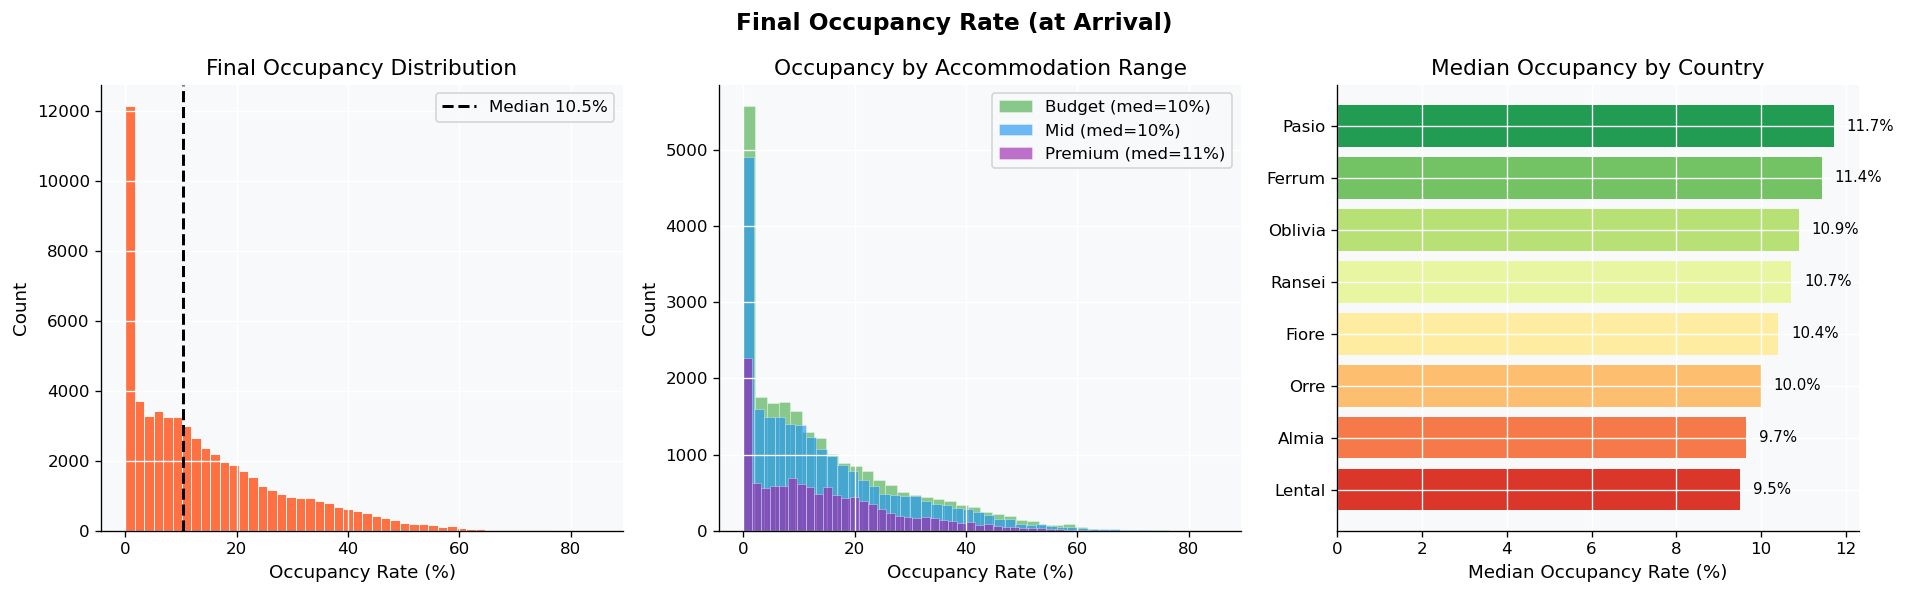

In [7]:
# Final outcome: WeekBeforeArrival == 0
final = df[df['WeekBeforeArrival'] == 0].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.hist(final['FillPct'], bins=50, color='#FF7043', edgecolor='white', linewidth=0.5)
ax.axvline(final['FillPct'].median(), color='black', lw=1.8, linestyle='--',
           label=f"Median {final['FillPct'].median():.1f}%")
ax.set_xlabel('Occupancy Rate (%)')
ax.set_ylabel('Count')
ax.set_title('Final Occupancy Distribution')
ax.legend()

ax = axes[1]
for rng, color in RANGE_COLORS.items():
    sub = final[final['AccommodationRange'] == rng]['FillPct']
    ax.hist(sub, bins=40, alpha=0.65, color=color,
            label=f'{rng} (med={sub.median():.0f}%)', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Occupancy Rate (%)')
ax.set_ylabel('Count')
ax.set_title('Occupancy by Accommodation Range')
ax.legend()

ax = axes[2]
country_occ = final.groupby('CampsiteCountry')['FillPct'].median().sort_values()
colors_occ = sns.color_palette('RdYlGn', len(country_occ))
bars = ax.barh(country_occ.index, country_occ.values, color=colors_occ)
for bar, val in zip(bars, country_occ.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Median Occupancy Rate (%)')
ax.set_title('Median Occupancy by Country')

fig.suptitle('Final Occupancy Rate (at Arrival)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig04_occupancy.png', bbox_inches='tight')
plt.show()

## 4. Seasonal Patterns

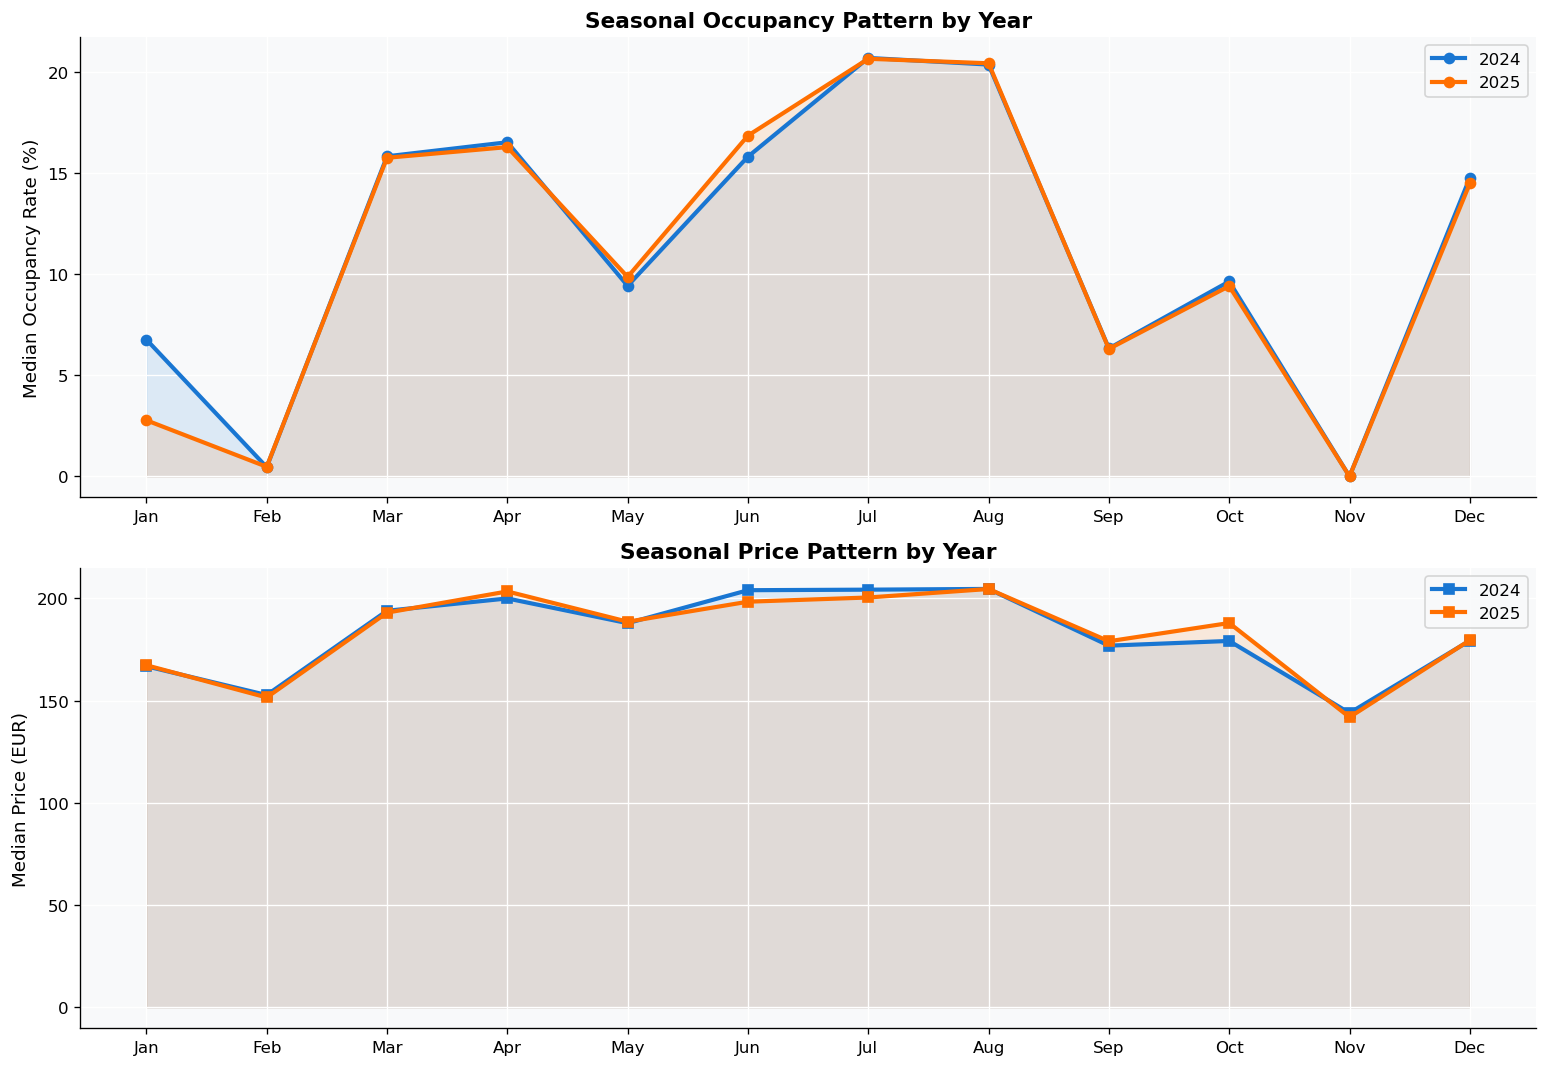

In [8]:
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly = final.groupby(['ArrivalMonth', 'Year']).agg(
    MedianOccupancy=('FillPct', 'median'),
    MedianPrice=('DiscountedPrice', 'median'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

ax = axes[0]
year_colors = {2024: '#1976D2', 2025: '#FF6F00'}
for year, color in year_colors.items():
    sub = monthly[monthly['Year'] == year].sort_values('ArrivalMonth')
    ax.plot(sub['ArrivalMonth'], sub['MedianOccupancy'], marker='o', lw=2.5,
            color=color, label=str(year))
    ax.fill_between(sub['ArrivalMonth'], sub['MedianOccupancy'], alpha=0.12, color=color)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel('Median Occupancy Rate (%)')
ax.set_title('Seasonal Occupancy Pattern by Year', fontweight='bold')
ax.legend()

ax = axes[1]
for year, color in year_colors.items():
    sub = monthly[monthly['Year'] == year].sort_values('ArrivalMonth')
    ax.plot(sub['ArrivalMonth'], sub['MedianPrice'], marker='s', lw=2.5,
            color=color, label=str(year))
    ax.fill_between(sub['ArrivalMonth'], sub['MedianPrice'], alpha=0.12, color=color)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel('Median Price (EUR)')
ax.set_title('Seasonal Price Pattern by Year', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('fig05_seasonal_patterns.png', bbox_inches='tight')
plt.show()

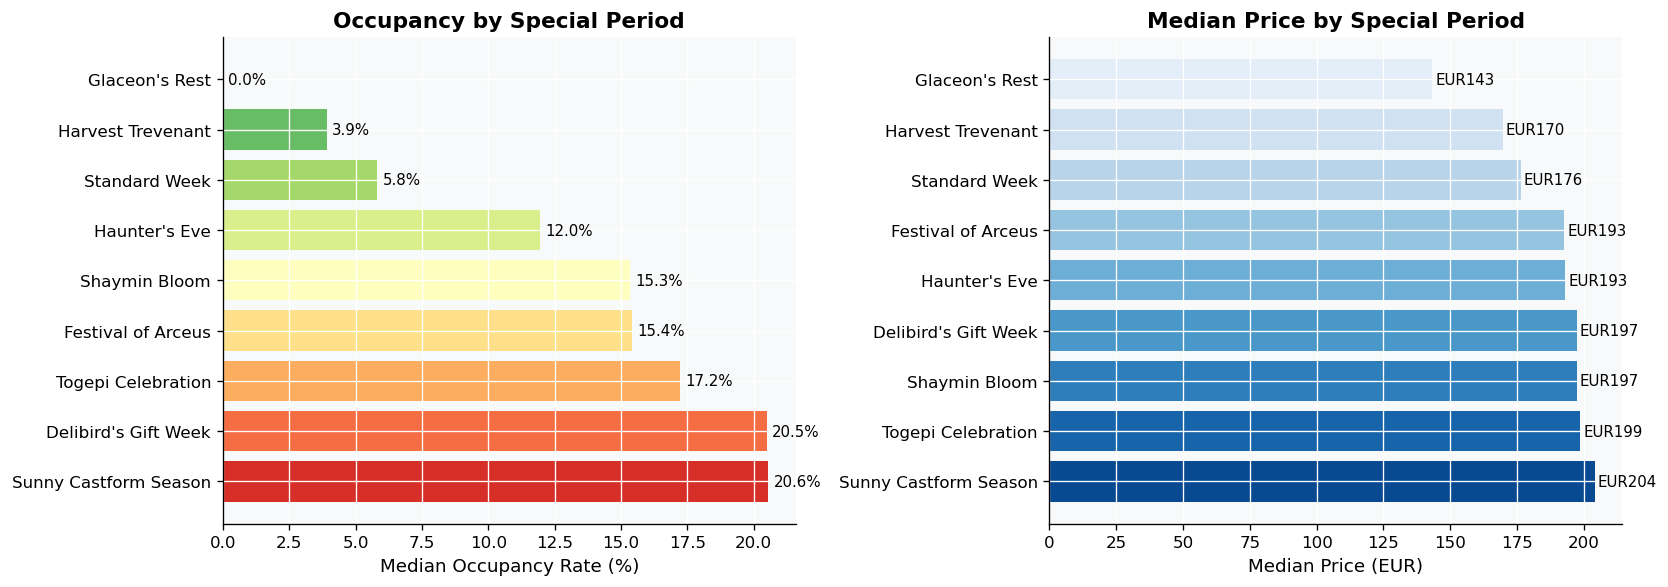

    SpecialPeriodCode  MedianOccupancy  MedianPrice  Count
Sunny Castform Season        20.552104      204.100  13632
 Delibird's Gift Week        20.486865      197.220   3408
   Togepi Celebration        17.210049      198.695   4544
   Festival of Arceus        15.419301      192.720   3408
        Shaymin Bloom        15.338328      197.355   7952
        Haunter's Eve        11.954023      193.045   4544
        Standard Week         5.816211      176.325   7952
    Harvest Trevenant         3.908046      169.670   2272
       Glaceon's Rest         0.000000      143.285  11360


In [9]:
special_stats = final.groupby('SpecialPeriodCode').agg(
    MedianOccupancy=('FillPct', 'median'),
    MedianPrice=('DiscountedPrice', 'median'),
    Count=('FillPct', 'count')
).sort_values('MedianOccupancy', ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors_sp = sns.color_palette('RdYlGn', len(special_stats))
bars = ax.barh(special_stats['SpecialPeriodCode'], special_stats['MedianOccupancy'], color=colors_sp)
for bar, val in zip(bars, special_stats['MedianOccupancy']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2, f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Median Occupancy Rate (%)')
ax.set_title('Occupancy by Special Period', fontweight='bold')

ax = axes[1]
price_order = special_stats.sort_values('MedianPrice', ascending=False)
bars = ax.barh(price_order['SpecialPeriodCode'], price_order['MedianPrice'],
               color=sns.color_palette('Blues_r', len(price_order)))
for bar, val in zip(bars, price_order['MedianPrice']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f'EUR{val:.0f}', va='center', fontsize=9)
ax.set_xlabel('Median Price (EUR)')
ax.set_title('Median Price by Special Period', fontweight='bold')

plt.tight_layout()
plt.savefig('fig06_special_periods.png', bbox_inches='tight')
plt.show()

print(special_stats[['SpecialPeriodCode','MedianOccupancy','MedianPrice','Count']].to_string(index=False))

## 5. Booking Curve Analysis

Each product's booking curve traces cumulative bookings from 52 weeks before arrival down to 0. The **shape** of this curve tells us:
- **When** demand arrives (early vs. last-minute segments)
- **Where** to intervene with price changes to maximise fill

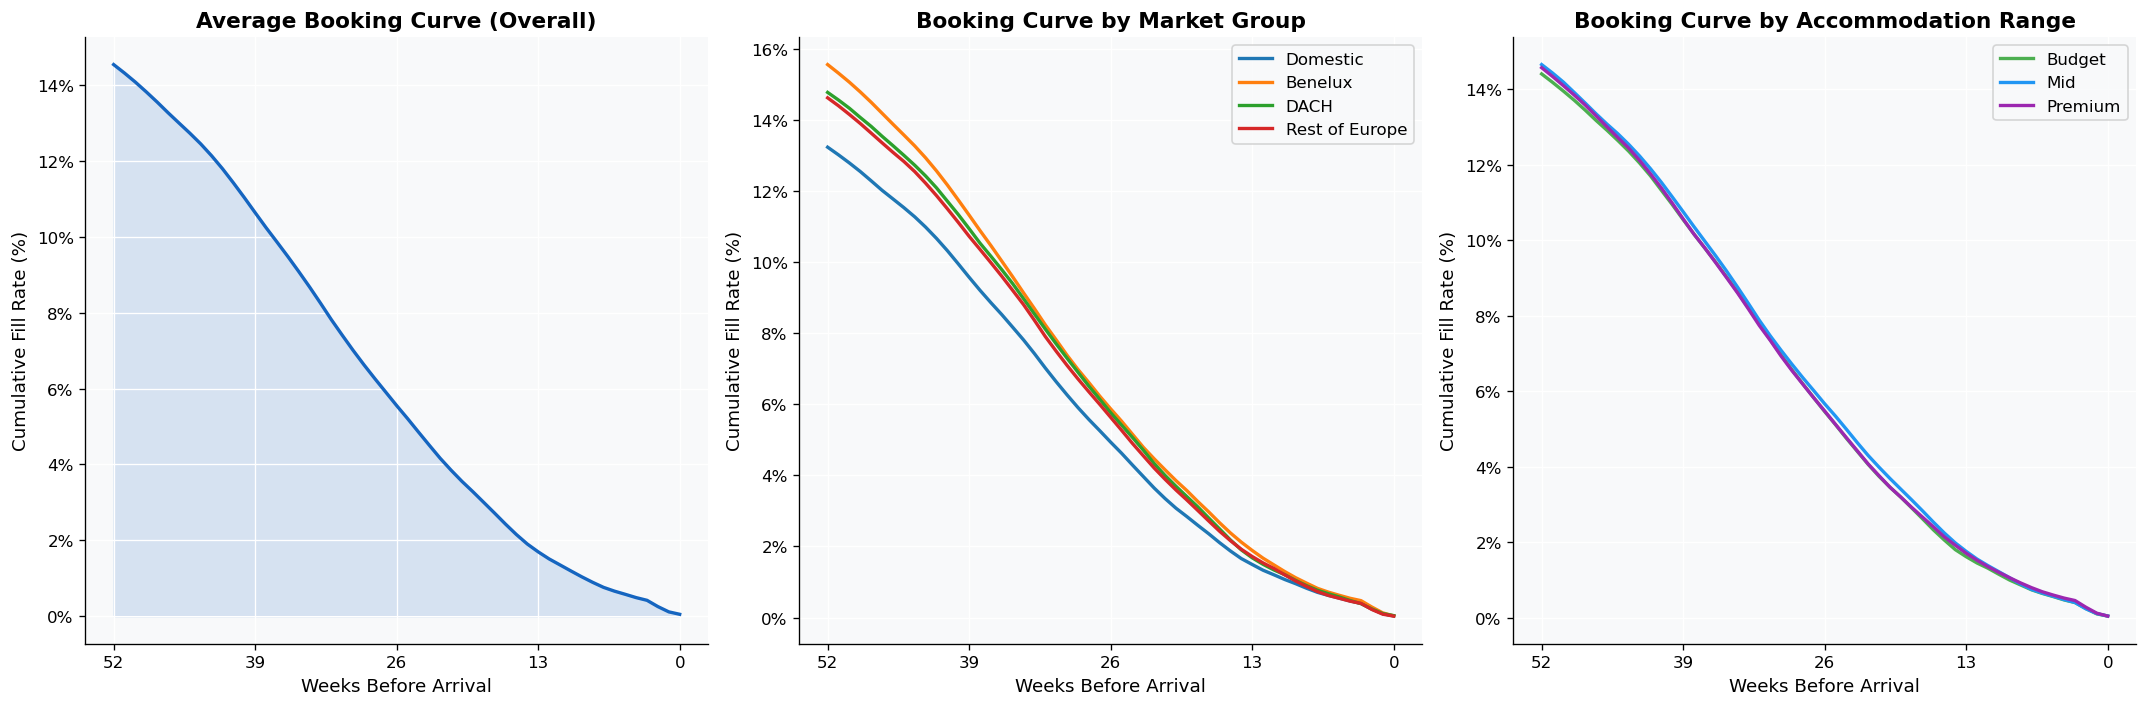

In [10]:
np.random.seed(42)
sample_ids = np.random.choice(df['ReservableOptionMarketGroupId'].unique(), size=5000, replace=False)
sample = df[df['ReservableOptionMarketGroupId'].isin(sample_ids)].copy()
sample = sample.sort_values(['ReservableOptionMarketGroupId', 'WeekBeforeArrival'])
sample['CumBooked'] = sample.groupby('ReservableOptionMarketGroupId')['HistoricalBookedNights'].cumsum()
sample['CumFill'] = (sample['CumBooked'] / sample['Capacity'] * 100).clip(0, 100)

curve_overall = sample.groupby('WeekBeforeArrival')['CumFill'].mean()
curve_by_market = sample.groupby(['WeekBeforeArrival','MarketGroupCode'])['CumFill'].mean().reset_index()
curve_by_range = sample.groupby(['WeekBeforeArrival','AccommodationRange'])['CumFill'].mean().reset_index()

def plot_curve(data, weeks_col, fill_col, ax, label='', color='#1565C0'):
    sub = data.sort_values(weeks_col, ascending=False)
    x = range(len(sub))
    ax.plot(x, sub[fill_col].values, lw=2, color=color, label=label)
    ax.set_xticks([0, 13, 26, 39, 52])
    ax.set_xticklabels(['52','39','26','13','0'])
    ax.set_xlabel('Weeks Before Arrival')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ax = axes[0]
plot_curve(curve_overall.reset_index(), 'WeekBeforeArrival', 'CumFill', ax, color='#1565C0')
ax.fill_between(range(53),
                curve_overall.sort_index(ascending=False).values, alpha=0.15, color='#1565C0')
ax.set_ylabel('Cumulative Fill Rate (%)')
ax.set_title('Average Booking Curve (Overall)', fontweight='bold')

ax = axes[1]
for mkt, color in MARKET_COLORS.items():
    sub = curve_by_market[curve_by_market['MarketGroupCode'] == mkt]
    plot_curve(sub, 'WeekBeforeArrival', 'CumFill', ax, label=mkt, color=color)
ax.set_ylabel('Cumulative Fill Rate (%)')
ax.set_title('Booking Curve by Market Group', fontweight='bold')
ax.legend()

ax = axes[2]
for rng, color in RANGE_COLORS.items():
    sub = curve_by_range[curve_by_range['AccommodationRange'] == rng]
    plot_curve(sub, 'WeekBeforeArrival', 'CumFill', ax, label=rng, color=color)
ax.set_ylabel('Cumulative Fill Rate (%)')
ax.set_title('Booking Curve by Accommodation Range', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('fig07_booking_curves.png', bbox_inches='tight')
plt.show()

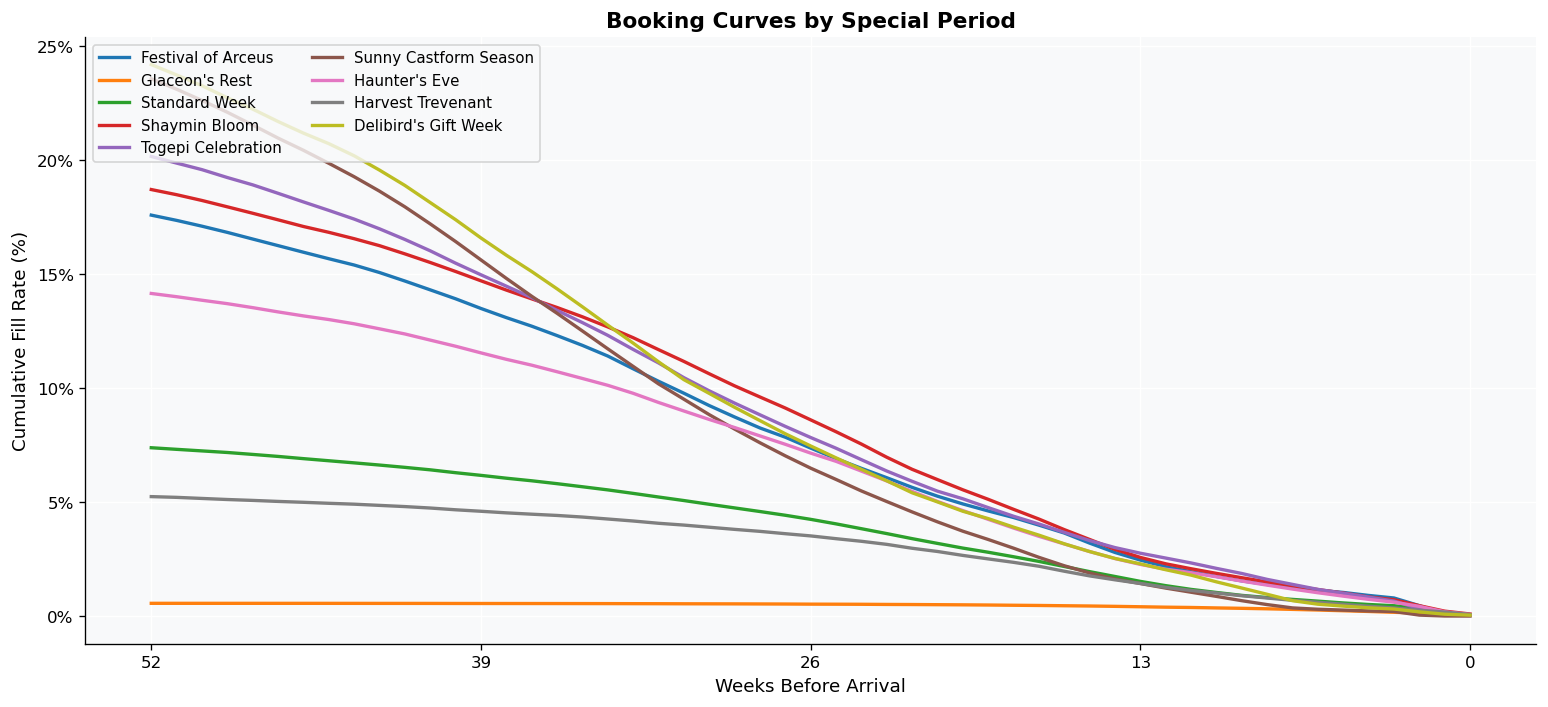

In [11]:
curve_by_special = sample.groupby(['WeekBeforeArrival','SpecialPeriodCode'])['CumFill'].mean().reset_index()

fig, ax = plt.subplots(figsize=(13, 6))
colors_sp = sns.color_palette('tab10', 9)
for period, color in zip(df['SpecialPeriodCode'].unique(), colors_sp):
    sub = curve_by_special[curve_by_special['SpecialPeriodCode'] == period]
    if len(sub) == 0:
        continue
    plot_curve(sub, 'WeekBeforeArrival', 'CumFill', ax, label=period, color=color)
ax.set_ylabel('Cumulative Fill Rate (%)')
ax.set_title('Booking Curves by Special Period', fontweight='bold')
ax.legend(loc='upper left', ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('fig08_booking_curve_special.png', bbox_inches='tight')
plt.show()

## 6. Price Elasticity — Does Price Affect Bookings?

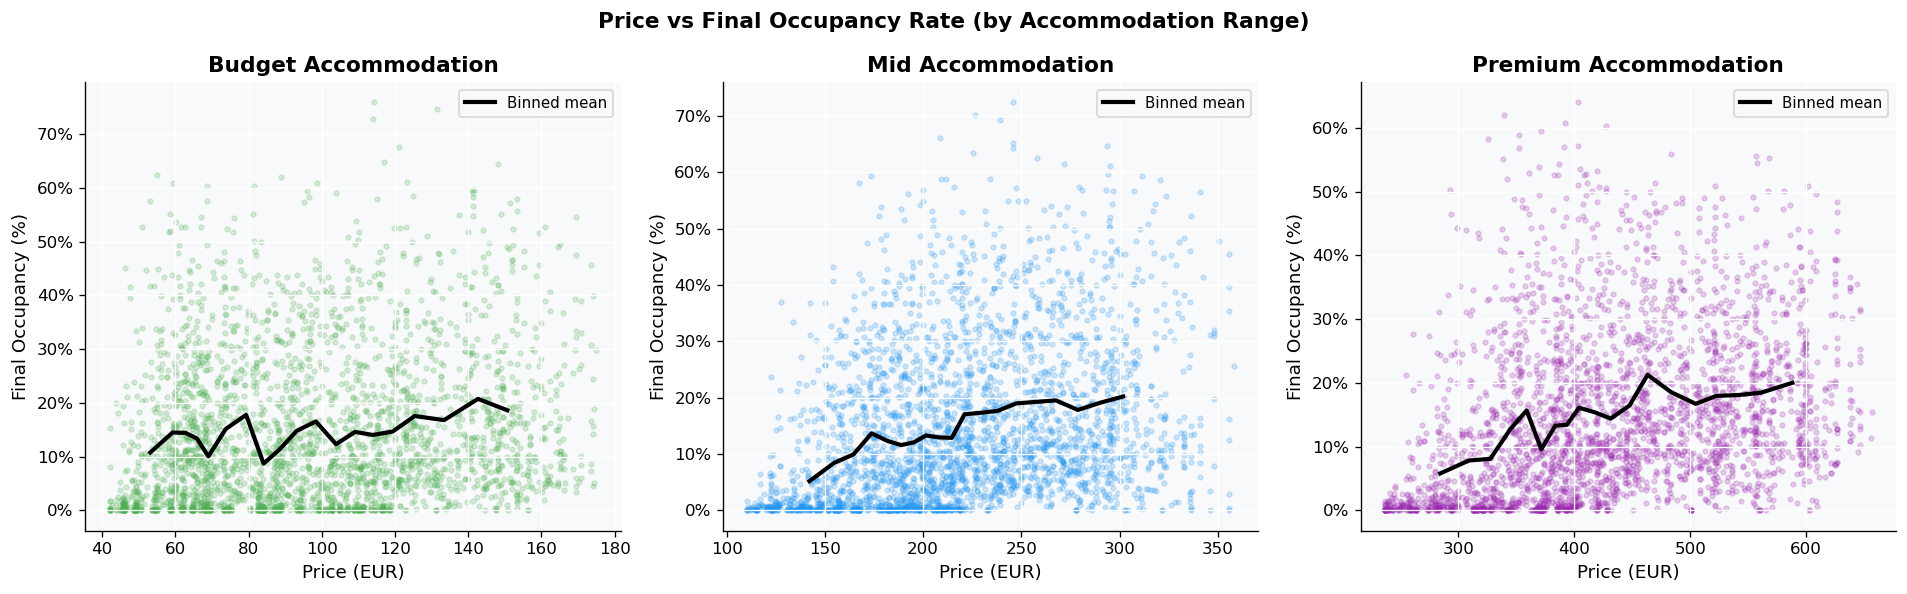

In [12]:
from scipy.stats import binned_statistic

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (rng, color) in zip(axes, RANGE_COLORS.items()):
    sub = final[final['AccommodationRange'] == rng].sample(
        min(3000, len(final[final['AccommodationRange'] == rng])), random_state=42)
    ax.scatter(sub['DiscountedPrice'], sub['FillPct'], alpha=0.2, s=8, color=color)
    # Binned mean trend line
    bins = np.percentile(sub['DiscountedPrice'], np.linspace(5, 95, 20))
    bins = np.unique(bins)
    if len(bins) > 2:
        bm_price, _, _ = binned_statistic(sub['DiscountedPrice'], sub['DiscountedPrice'], bins=bins)
        bm_occ, _, _ = binned_statistic(sub['DiscountedPrice'], sub['FillPct'], bins=bins)
        valid = ~np.isnan(bm_price) & ~np.isnan(bm_occ)
        ax.plot(bm_price[valid], bm_occ[valid], color='black', lw=2.5, label='Binned mean')
    ax.set_xlabel('Price (EUR)')
    ax.set_ylabel('Final Occupancy (%)')
    ax.set_title(f'{rng} Accommodation', fontweight='bold')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
    ax.legend(fontsize=9)

fig.suptitle('Price vs Final Occupancy Rate (by Accommodation Range)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig09_price_elasticity.png', bbox_inches='tight')
plt.show()

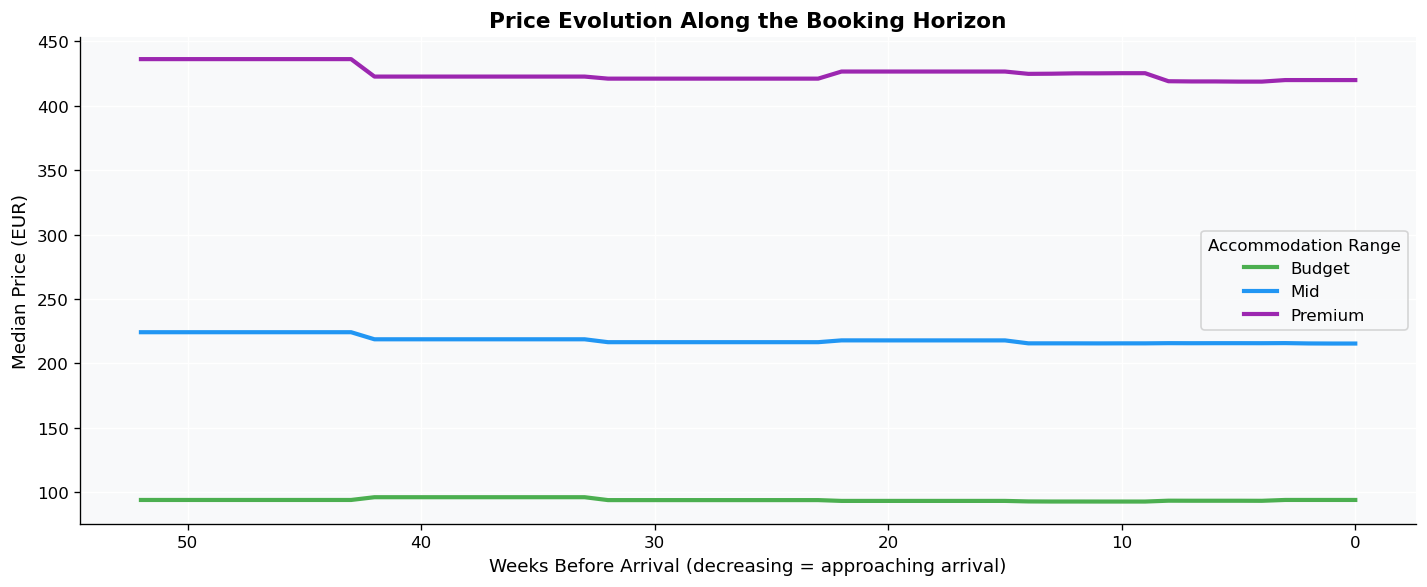

In [13]:
# How does median price change along the booking horizon?
price_curve = df.groupby(['WeekBeforeArrival','AccommodationRange'])['DiscountedPrice'].median().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for rng, color in RANGE_COLORS.items():
    sub = price_curve[price_curve['AccommodationRange'] == rng].sort_values('WeekBeforeArrival')
    ax.plot(sub['WeekBeforeArrival'], sub['DiscountedPrice'], lw=2.5, color=color, label=rng)
ax.invert_xaxis()
ax.set_xlabel('Weeks Before Arrival (decreasing = approaching arrival)')
ax.set_ylabel('Median Price (EUR)')
ax.set_title('Price Evolution Along the Booking Horizon', fontweight='bold')
ax.legend(title='Accommodation Range')
plt.tight_layout()
plt.savefig('fig10_price_horizon.png', bbox_inches='tight')
plt.show()

## 7. Market Group Analysis

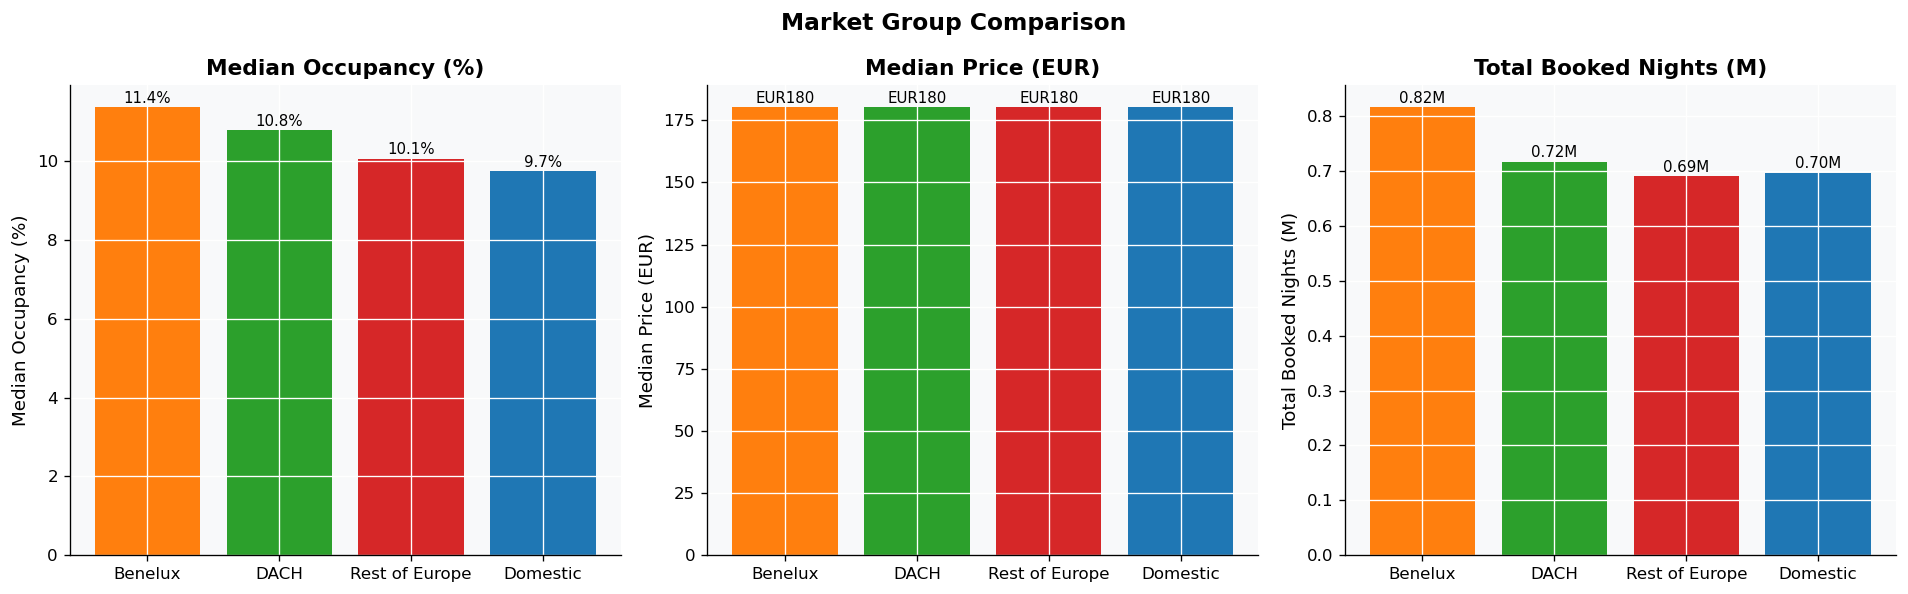

In [14]:
mkt_stats = final.groupby('MarketGroupCode').agg(
    MedianOccupancy=('FillPct', 'median'),
    MedianPrice=('DiscountedPrice', 'median'),
    TotalNights=('TotalBookedNights', 'sum'),
).reset_index().sort_values('MedianOccupancy', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (col, ylabel, fmt) in zip(axes, [
    ('MedianOccupancy', 'Median Occupancy (%)', '{:.1f}%'),
    ('MedianPrice', 'Median Price (EUR)', 'EUR{:.0f}'),
    ('TotalNights', 'Total Booked Nights (M)', '{:.2f}M'),
]):
    vals = mkt_stats[col] / (1e6 if col == 'TotalNights' else 1)
    bars = ax.bar(mkt_stats['MarketGroupCode'], vals,
                  color=[MARKET_COLORS[m] for m in mkt_stats['MarketGroupCode']])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(vals) * 0.01,
                fmt.format(val), ha='center', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight='bold')

fig.suptitle('Market Group Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_market_groups.png', bbox_inches='tight')
plt.show()

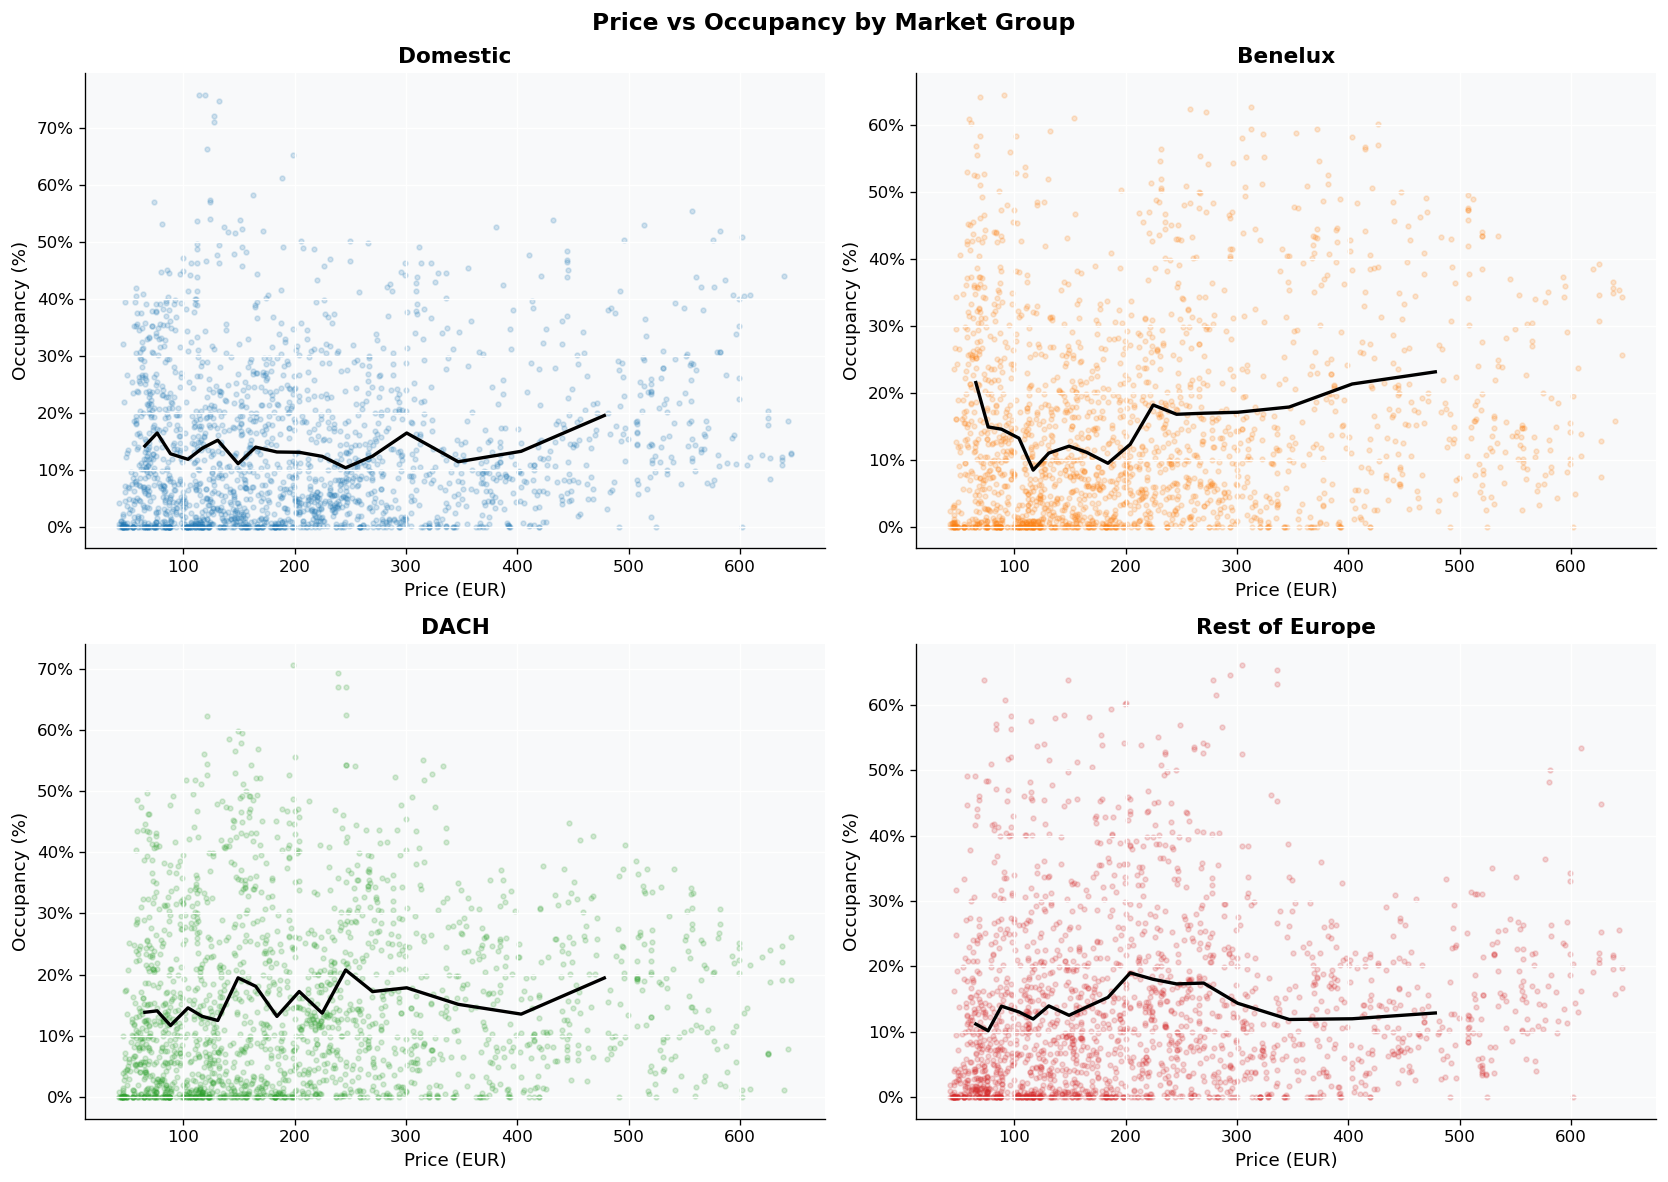

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, mkt in zip(axes, ['Domestic', 'Benelux', 'DACH', 'Rest of Europe']):
    sub = final[final['MarketGroupCode'] == mkt].sample(
        min(2000, len(final[final['MarketGroupCode'] == mkt])), random_state=42)
    ax.scatter(sub['DiscountedPrice'], sub['FillPct'], alpha=0.18, s=8, color=MARKET_COLORS[mkt])
    bins = np.unique(np.percentile(sub['DiscountedPrice'], np.linspace(5, 95, 18)))
    if len(bins) > 2:
        bm_price, _, _ = binned_statistic(sub['DiscountedPrice'], sub['DiscountedPrice'], bins=bins)
        bm_occ, _, _ = binned_statistic(sub['DiscountedPrice'], sub['FillPct'], bins=bins)
        valid = ~np.isnan(bm_price) & ~np.isnan(bm_occ)
        ax.plot(bm_price[valid], bm_occ[valid], color='black', lw=2)
    ax.set_title(mkt, fontweight='bold')
    ax.set_xlabel('Price (EUR)')
    ax.set_ylabel('Occupancy (%)')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))

fig.suptitle('Price vs Occupancy by Market Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig12_price_sensitivity_market.png', bbox_inches='tight')
plt.show()

## 8. Accommodation Features Impact

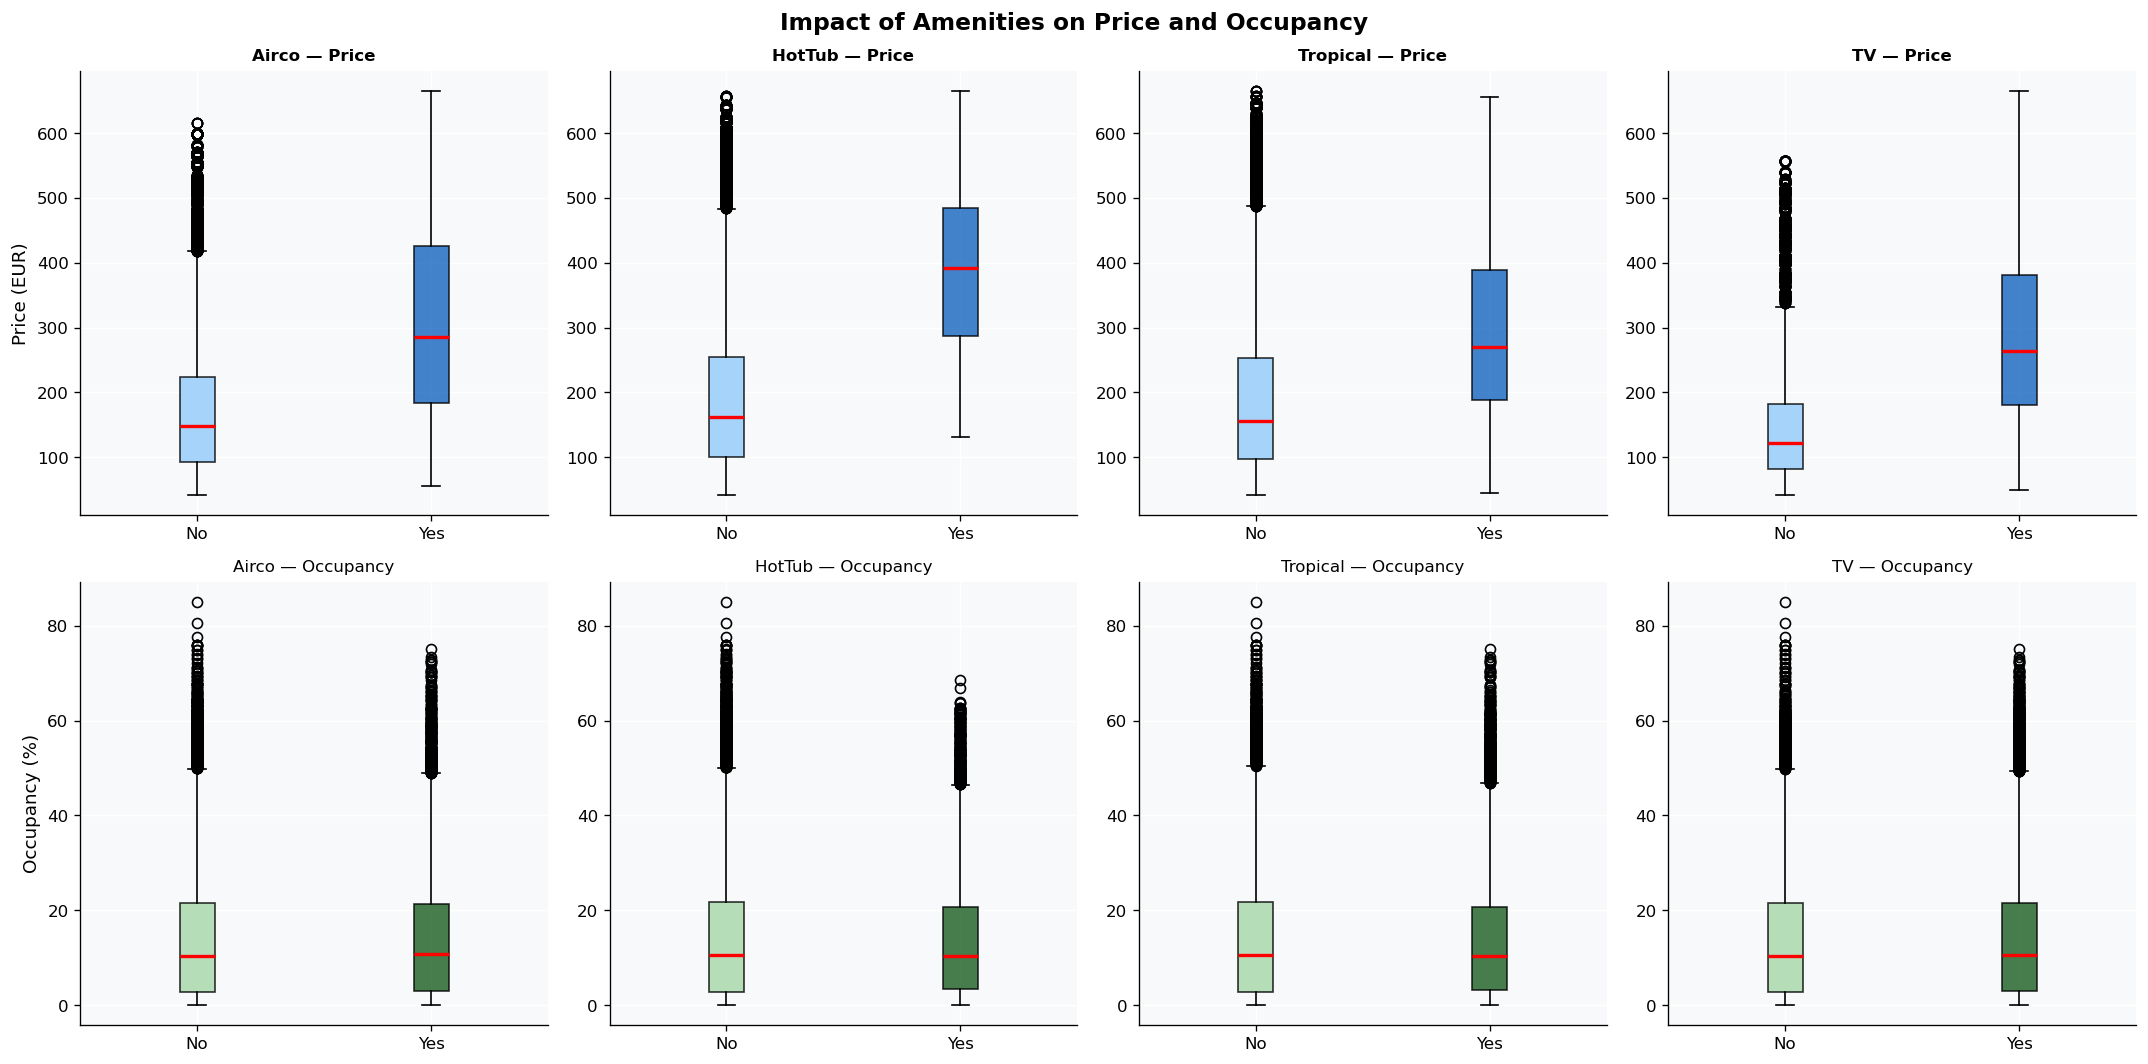

In [16]:
amenities = ['Airco', 'HotTub', 'Tropical', 'TV']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col_idx, amenity in enumerate(amenities):
    ax_price = axes[0, col_idx]
    ax_occ = axes[1, col_idx]

    price_no = final[final[amenity] == 0]['DiscountedPrice']
    price_yes = final[final[amenity] == 1]['DiscountedPrice']
    occ_no = final[final[amenity] == 0]['FillPct']
    occ_yes = final[final[amenity] == 1]['FillPct']

    bp1 = ax_price.boxplot([price_no, price_yes], labels=['No', 'Yes'], patch_artist=True,
                           medianprops=dict(color='red', lw=2))
    for patch, c in zip(bp1['boxes'], ['#90CAF9', '#1565C0']):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax_price.set_title(f'{amenity} — Price', fontweight='bold', fontsize=10)
    if col_idx == 0:
        ax_price.set_ylabel('Price (EUR)')

    bp2 = ax_occ.boxplot([occ_no, occ_yes], labels=['No', 'Yes'], patch_artist=True,
                         medianprops=dict(color='red', lw=2))
    for patch, c in zip(bp2['boxes'], ['#A5D6A7', '#1B5E20']):
        patch.set_facecolor(c)
        patch.set_alpha(0.8)
    ax_occ.set_title(f'{amenity} — Occupancy', fontsize=10)
    if col_idx == 0:
        ax_occ.set_ylabel('Occupancy (%)')

fig.suptitle('Impact of Amenities on Price and Occupancy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig13_amenities.png', bbox_inches='tight')
plt.show()

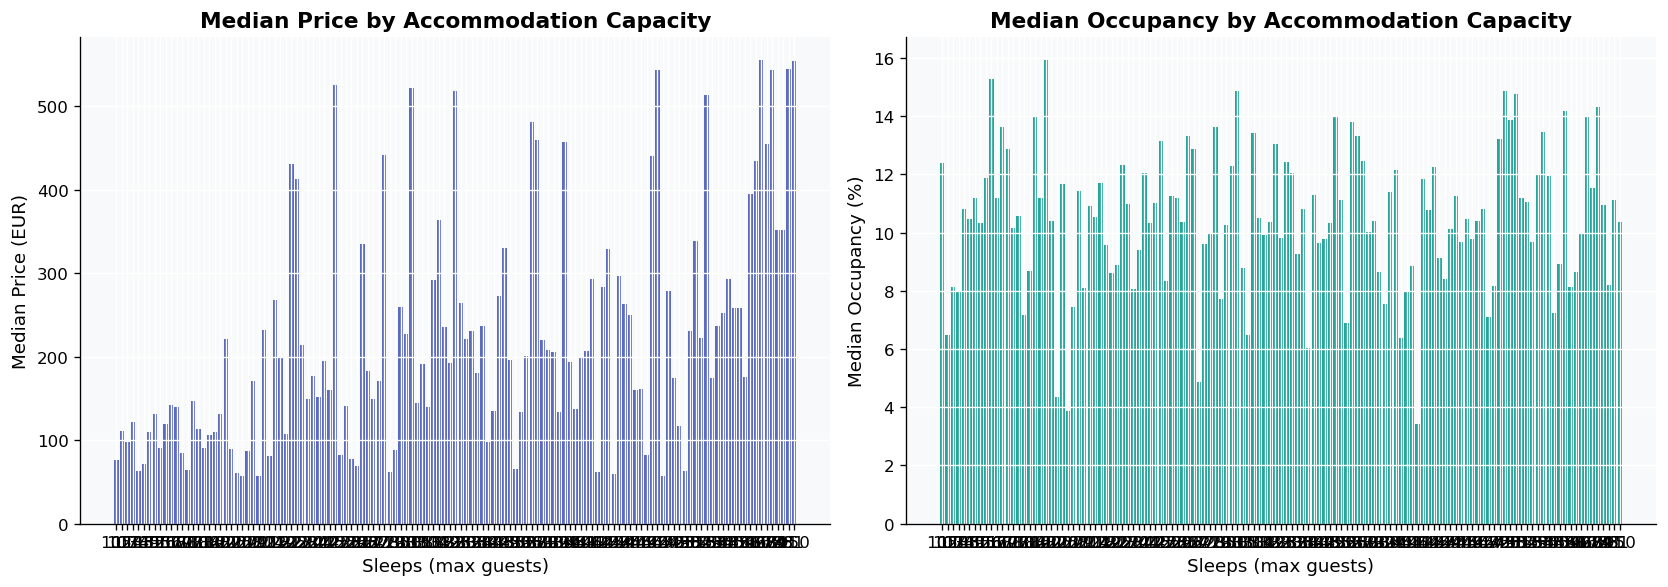

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sleeps_stats = final.groupby('Sleeps').agg(
    MedianPrice=('DiscountedPrice', 'median'),
    MedianOcc=('FillPct', 'median'),
    Count=('FillPct', 'count')
).reset_index().sort_values('Sleeps')

ax = axes[0]
ax.bar(sleeps_stats['Sleeps'].astype(str), sleeps_stats['MedianPrice'], color='#5C6BC0')
ax.set_xlabel('Sleeps (max guests)')
ax.set_ylabel('Median Price (EUR)')
ax.set_title('Median Price by Accommodation Capacity', fontweight='bold')

ax = axes[1]
ax.bar(sleeps_stats['Sleeps'].astype(str), sleeps_stats['MedianOcc'], color='#26A69A')
ax.set_xlabel('Sleeps (max guests)')
ax.set_ylabel('Median Occupancy (%)')
ax.set_title('Median Occupancy by Accommodation Capacity', fontweight='bold')

plt.tight_layout()
plt.savefig('fig14_sleeps.png', bbox_inches='tight')
plt.show()

## 9. Year-over-Year Comparison

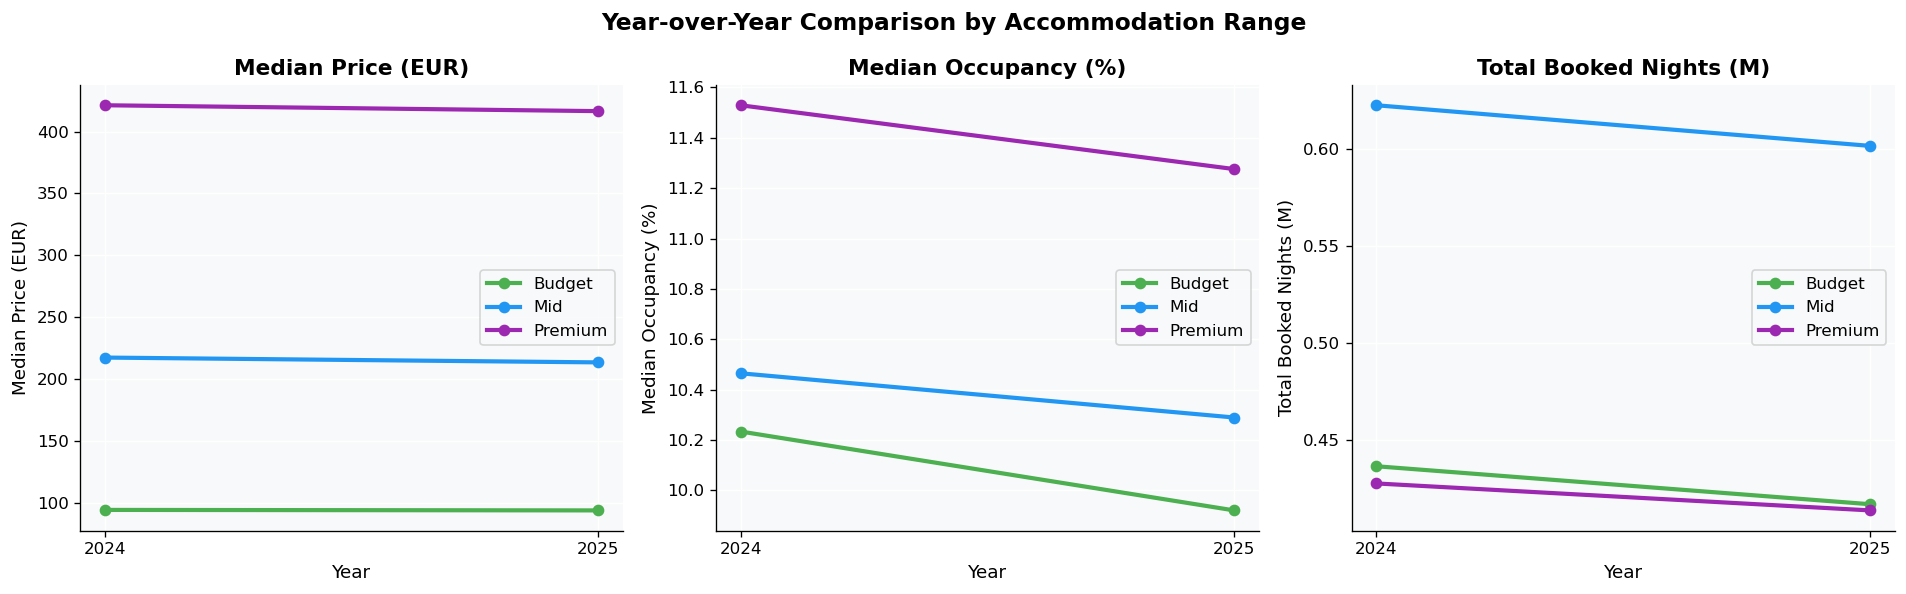

In [18]:
yoy = final.groupby(['Year', 'AccommodationRange']).agg(
    MedianPrice=('DiscountedPrice', 'median'),
    MedianOcc=('FillPct', 'median'),
    TotalNights=('TotalBookedNights', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (metric, ylabel, scale) in zip(axes, [
    ('MedianPrice', 'Median Price (EUR)', 1),
    ('MedianOcc', 'Median Occupancy (%)', 1),
    ('TotalNights', 'Total Booked Nights (M)', 1e6),
]):
    for rng, color in RANGE_COLORS.items():
        sub = yoy[yoy['AccommodationRange'] == rng].sort_values('Year')
        ax.plot([2024, 2025], sub[metric].values / scale, marker='o', lw=2.5,
                color=color, label=rng)
    ax.set_xticks([2024, 2025])
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontweight='bold')
    ax.legend()

fig.suptitle('Year-over-Year Comparison by Accommodation Range', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig15_yoy.png', bbox_inches='tight')
plt.show()

## 10. Geographic Scatter Map

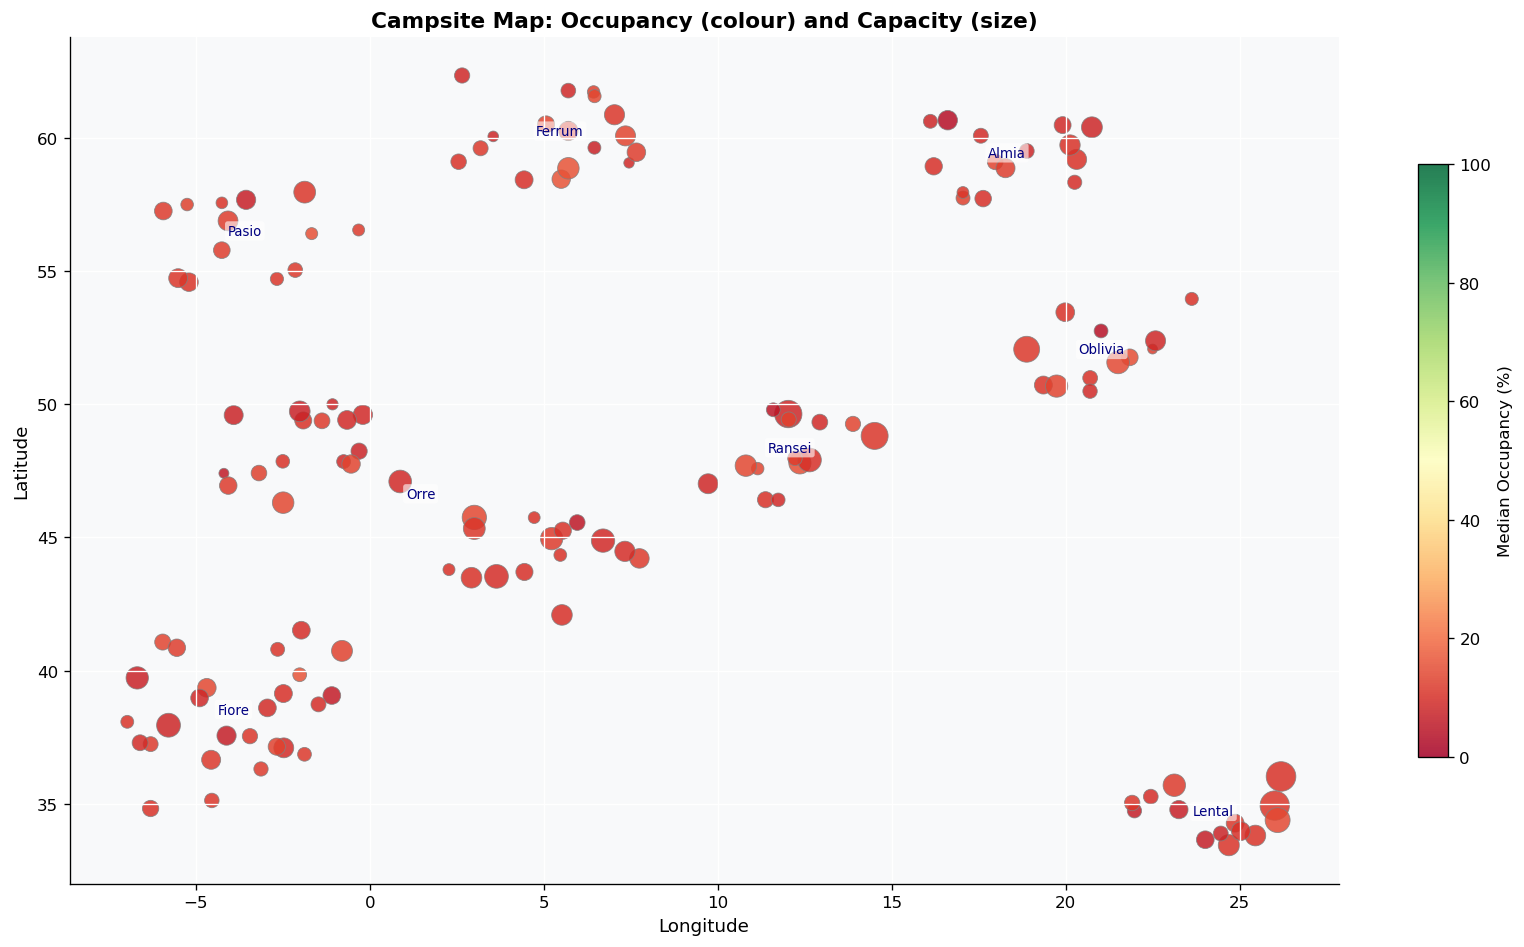

Top 10 campsites by median occupancy:
CampsiteCode Country  MedianOcc  MedianPrice  Capacity
    Basculin  Ferrum       16.0        157.5     366.0
      Gogoat   Fiore       15.9        131.9     206.5
     Scrafty  Ferrum       15.8        387.4     501.0
    Weavile1   Pasio       15.3        119.0     157.0
  Charjabug1  Ransei       14.9        116.6     531.5
      Rhydon Oblivia       14.9        522.3     303.0
  Toedscool1  Lental       14.3        543.0     674.0
     Wattrel Oblivia       14.2        257.9     554.0
   Cobalion1    Orre       14.0        555.1     638.5
  Darmanitan   Fiore       14.0        196.4     375.5


In [19]:
campsite_geo = final.groupby('CampsiteCode').agg(
    lat=('latitude', 'first'),
    lon=('longitude', 'first'),
    MedianOcc=('FillPct', 'median'),
    MedianPrice=('DiscountedPrice', 'median'),
    Capacity=('Capacity', 'median'),
    Country=('CampsiteCountry', 'first')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(
    campsite_geo['lon'], campsite_geo['lat'],
    c=campsite_geo['MedianOcc'], cmap='RdYlGn',
    s=campsite_geo['Capacity'] / 3,
    alpha=0.85, edgecolors='grey', linewidths=0.5, vmin=0, vmax=100
)
cbar = plt.colorbar(scatter, ax=ax, shrink=0.7)
cbar.set_label('Median Occupancy (%)', fontsize=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Campsite Map: Occupancy (colour) and Capacity (size)', fontweight='bold')

# Country labels
for country, grp in campsite_geo.groupby('Country'):
    ax.annotate(country, (grp['lon'].mean(), grp['lat'].mean()),
                fontsize=8, ha='center', color='navy',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, ec='none'))

plt.tight_layout()
plt.savefig('fig16_geo_map.png', bbox_inches='tight')
plt.show()

print("Top 10 campsites by median occupancy:")
print(campsite_geo.nlargest(10, 'MedianOcc')
      [['CampsiteCode','Country','MedianOcc','MedianPrice','Capacity']]
      .round(1).to_string(index=False))

## 11. Correlation Heatmap

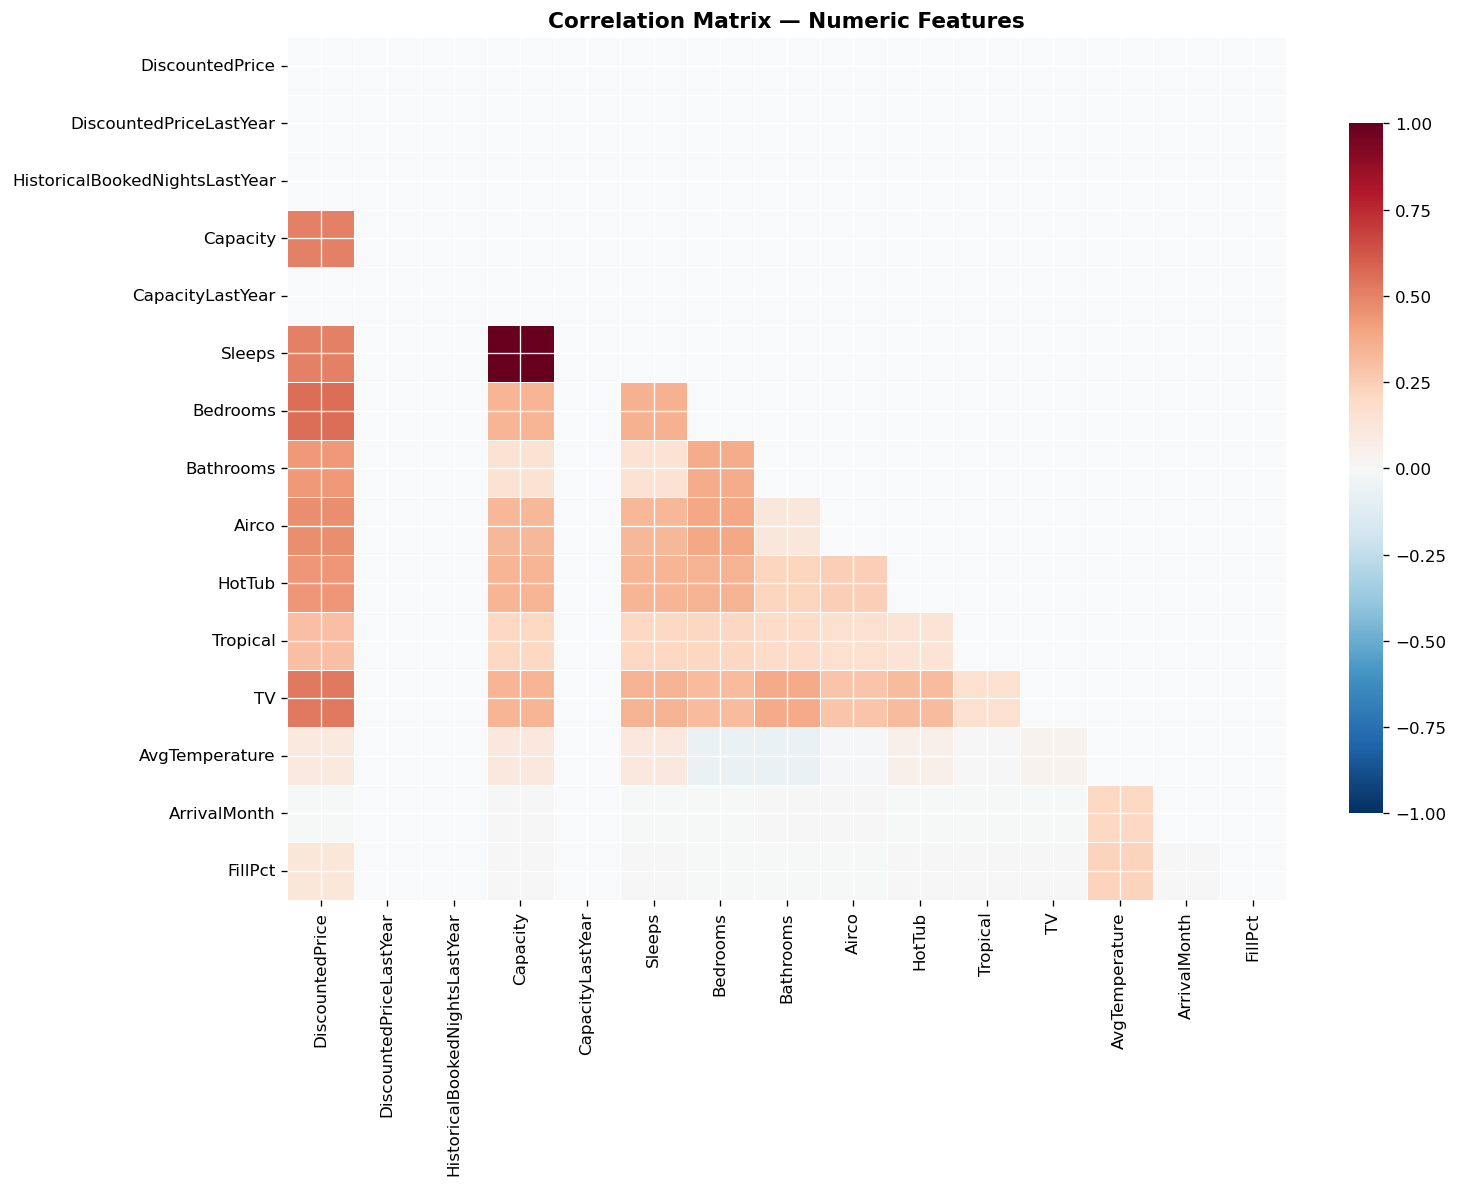

In [20]:
num_features = ['DiscountedPrice','DiscountedPriceLastYear','HistoricalBookedNightsLastYear',
                'Capacity','CapacityLastYear','Sleeps','Bedrooms','Bathrooms',
                'Airco','HotTub','Tropical','TV','AvgTemperature','ArrivalMonth','FillPct']

corr_df = final[num_features].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig17_correlation.png', bbox_inches='tight')
plt.show()

## 12. Key Insights Summary

| Dimension | Finding |
|-----------|----------|
| **Seasonality** | Clear occupancy peak Jun–Aug; prices and occupancy both rise together — pricing power is real in summer |
| **Booking horizon** | Most bookings arrive in the final 13 weeks; early-bird pricing can smooth demand |
| **Price elasticity** | Negative price–occupancy relationship visible in all ranges; stronger for Budget than Premium |
| **Accommodation range** | Premium earns 2–3× higher price but not proportionally more bookings — revenue comes from margin, not volume |
| **Market groups** | Domestic and Benelux show higher median occupancy; all four groups follow similar price sensitivity curves |
| **Special periods** | Holiday periods command premium prices AND higher occupancy — the most valuable pricing moments |
| **Amenities** | HotTub and Airco associated with meaningfully higher prices; TV adds minimal premium |
| **Geography** | Occupancy varies significantly by country; warm climate alone does not guarantee high occupancy |
| **Year-over-year** | Prices increased YoY across all ranges; occupancy trends remain broadly stable |

---

## 13. Recommended Next Steps

1. **Feature engineering**: create booking curve slope features, % fill at key horizons (26w, 13w, 4w), YoY fill ratio
2. **Train demand model**: LightGBM on incremental bookings `HistoricalBookedNights` with all features above
3. **Validate on 2025**: train on 2024, evaluate MAE and bias on 2025 weeks
4. **Price optimiser**: for each product, simulate revenue across a price grid using the model; pick argmax
5. **Cold-start rule**: apply cluster medians for any product with <4 weeks of history
6. **Dashboard**: weekly occupancy fill rate vs. target, price deviation from last year, revenue vs. forecast